<a href="https://colab.research.google.com/github/Hertfordshire-Data-Science-Hackathon/Group-F-RMDS-Hackathon/blob/main/Group_F_cat_and_xg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install and Import Libraries

In [1]:
!pip install catboost
!pip install xgboost
!pip install shap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.2 MB/s eta 0:00:00


In [2]:
# Import required modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, roc_auc_score, roc_curve, recall_score, precision_score, f1_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import PowerTransformer, OneHotEncoder
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier
import shap
from warnings import filterwarnings


# **EDA and Pre-processing**

In [3]:
train=pd.read_csv("dataset_A_training.csv")
test=pd.read_csv("dataset_A_testing.csv")

In [4]:
train.set_index = train['respondent_id']
test.set_index = test['respondent_id']

In [5]:
# Shape of the dataset
print(f'Data has {test.shape[0]} rows and {test.shape[1]} columns')

Data has 4749 rows and 30 columns


In [6]:
# General overview of the dataset
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                4756 non-null   int64  
 1   flu_concern                  4744 non-null   float64
 2   flu_knowledge                4733 non-null   float64
 3   behavioral_antiviral_meds    4742 non-null   float64
 4   behavioral_avoidance         4724 non-null   float64
 5   behavioral_face_mask         4753 non-null   float64
 6   behavioral_wash_hands        4748 non-null   float64
 7   behavioral_large_gatherings  4747 non-null   float64
 8   behavioral_outside_home      4747 non-null   float64
 9   behavioral_touch_face        4737 non-null   float64
 10  doctor_recc_seasonal         4435 non-null   float64
 11  chronic_med_condition        4568 non-null   float64
 12  child_under_6_months         4604 non-null   float64
 13  health_worker     

In [7]:
train.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
respondent_id,4756.0,2378.50,1373.08,1.0,1189.75,2378.5,3567.25,4756.0
flu_concern,4744.0,1.64,0.92,0.0,1.00,2.0,2.00,3.0
flu_knowledge,4733.0,1.29,0.62,0.0,1.00,1.0,2.00,2.0
behavioral_antiviral_meds,4742.0,0.05,0.22,0.0,0.00,0.0,0.00,1.0
behavioral_avoidance,4724.0,0.73,0.44,0.0,0.00,1.0,1.00,1.0
behavioral_face_mask,4753.0,0.07,0.26,0.0,0.00,0.0,0.00,1.0
behavioral_wash_hands,4748.0,0.84,0.37,0.0,1.00,1.0,1.00,1.0
behavioral_large_gatherings,4747.0,0.37,0.48,0.0,0.00,0.0,1.00,1.0
behavioral_outside_home,4747.0,0.34,0.47,0.0,0.00,0.0,1.00,1.0
behavioral_touch_face,4737.0,0.69,0.46,0.0,0.00,1.0,1.00,1.0


In [8]:
TARGET = 'seasonal_vaccine'

In [9]:
numeric_cols = train.select_dtypes(exclude=["object"]).columns
categorical_cols = train.select_dtypes(include=["object"]).columns

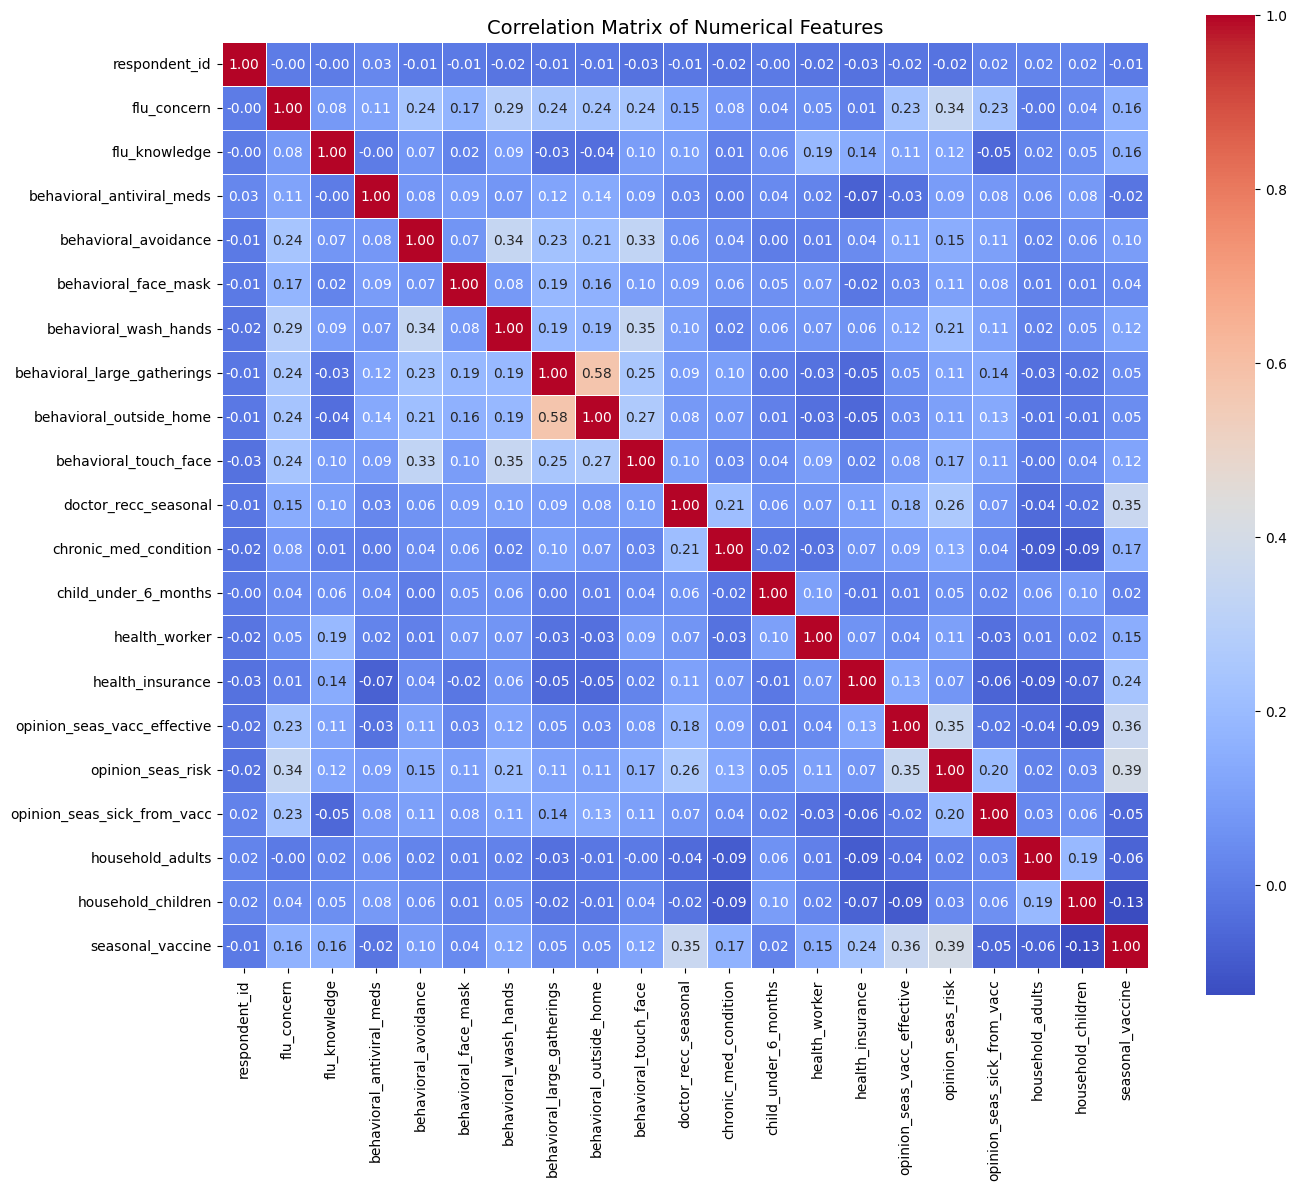

In [10]:
plt.figure(figsize=(14, 12))
sns.heatmap(train[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Matrix of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
(train.isnull().sum()/len(train)) * 100.0

,0
respondent_id,0.000000
flu_concern,0.252313
flu_knowledge,0.483600
behavioral_antiviral_meds,0.294365
behavioral_avoidance,0.672834
behavioral_face_mask,0.063078
behavioral_wash_hands,0.168209
behavioral_large_gatherings,0.189235
behavioral_outside_home,0.189235
behavioral_touch_face,0.399495


In [12]:
test.info()
test.describe().round(2).T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4749 entries, 0 to 4748
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                4749 non-null   int64  
 1   flu_concern                  4728 non-null   float64
 2   flu_knowledge                4731 non-null   float64
 3   behavioral_antiviral_meds    4735 non-null   float64
 4   behavioral_avoidance         4702 non-null   float64
 5   behavioral_face_mask         4746 non-null   float64
 6   behavioral_wash_hands        4743 non-null   float64
 7   behavioral_large_gatherings  4722 non-null   float64
 8   behavioral_outside_home      4737 non-null   float64
 9   behavioral_touch_face        4719 non-null   float64
 10  doctor_recc_seasonal         4404 non-null   float64
 11  chronic_med_condition        4581 non-null   float64
 12  child_under_6_months         4594 non-null   float64
 13  health_worker     

,count,mean,std,min,25%,50%,75%,max
respondent_id,4749.0,7131.00,1371.06,4757.0,5944.0,7131.0,8318.0,9505.0
flu_concern,4728.0,1.69,0.91,0.0,1.0,2.0,2.0,3.0
flu_knowledge,4731.0,1.28,0.63,0.0,1.0,1.0,2.0,2.0
behavioral_antiviral_meds,4735.0,0.05,0.22,0.0,0.0,0.0,0.0,1.0
behavioral_avoidance,4702.0,0.73,0.44,0.0,0.0,1.0,1.0,1.0
behavioral_face_mask,4746.0,0.08,0.27,0.0,0.0,0.0,0.0,1.0
behavioral_wash_hands,4743.0,0.84,0.37,0.0,1.0,1.0,1.0,1.0
behavioral_large_gatherings,4722.0,0.36,0.48,0.0,0.0,0.0,1.0,1.0
behavioral_outside_home,4737.0,0.34,0.47,0.0,0.0,0.0,1.0,1.0
behavioral_touch_face,4719.0,0.69,0.46,0.0,0.0,1.0,1.0,1.0


In [13]:
TARGET = "seasonal_vaccine"


/tmp/ipykernel_1280/549962953.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=TARGET, data=train, palette="pastel")


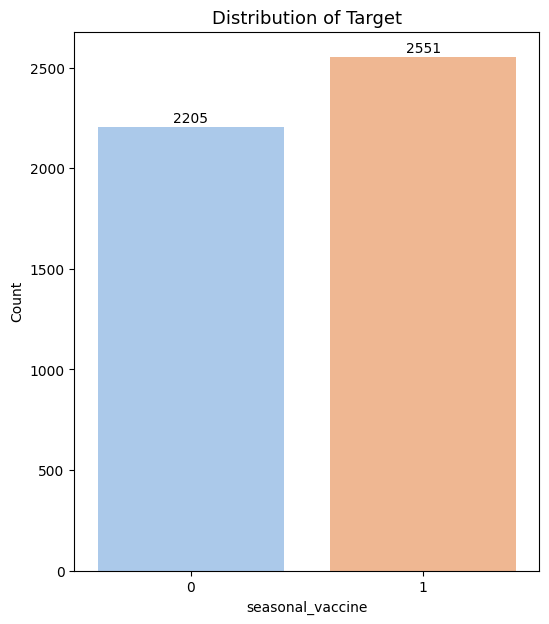

In [14]:
plt.figure(figsize=(6,7))
ax = sns.countplot(x=TARGET, data=train, palette="pastel")
plt.title('Distribution of Target', fontsize=13)
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+0.4, p.get_height()+10),
                ha='center', va='bottom', fontsize=10)
plt.show()

In [15]:
X = train.drop(columns=[TARGET])
y = train[TARGET]

In [16]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns


# Catboost

In [17]:
preprocessor = ColumnTransformer([
    (
        "num",
        SimpleImputer(strategy="median"),
        numeric_cols
    ),
    (
        "cat",
        Pipeline([
            ("imputer",
             SimpleImputer(strategy="most_frequent")),
            ("encoder",
             OneHotEncoder(handle_unknown="ignore"))
        ]),
        categorical_cols
    )
])


In [18]:
cat_features = X.select_dtypes(include=["object"]).columns.tolist()

X = X.copy()
X_test = test.copy()

for col in cat_features:
    X[col] = X[col].astype(str)
    X_test[col] = X_test[col].astype(str)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
f1_scores = []

for train_idx, val_idx in cv.split(X, y):
    X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
    y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

In [19]:
fold_model = CatBoostClassifier(
  iterations=1000,
  learning_rate=0.05,
  depth=6,
  loss_function="Logloss",
  eval_metric="F1",
  random_state=42,
  verbose=0,
  cat_features=cat_features
)

    # Fit the model for the current fold
fold_model.fit(X_train_fold, y_train_fold)

    # Predict on the validation fold
y_pred_fold = fold_model.predict(X_val_fold)

    # Calculate F1 score and store it
f1_scores.append(f1_score(y_val_fold, y_pred_fold))

# Calculate the mean F1 score across all folds
f1 = np.mean(f1_scores)

print("CV F1:", f1)

model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="F1",
    random_state=42,
    verbose=0,
    cat_features=cat_features
)
model.fit(X, y)
preds = model.predict(X_test)

submission = pd.DataFrame({
    "respondent_id": test["respondent_id"],
    "seasonal_vaccine": preds.astype(int)
})

submission.to_csv("catboost.csv", index=False)

CV F1: 0.7910592808551993


Accuracy: 0.8745
Precision: 0.8775
Recall: 0.8902
F1 Score: 0.8838

Confusion Matrix:
[[1888  317]
 [ 280 2271]]


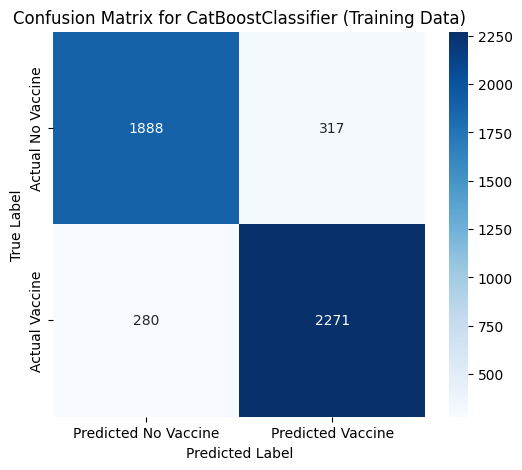

In [20]:
y_train_pred = model.predict(X)

# Calculate evaluation metrics
accuracy = accuracy_score(y, y_train_pred)
precision = precision_score(y, y_train_pred)
recall = recall_score(y, y_train_pred)
f1 = f1_score(y, y_train_pred)
conf_matrix = confusion_matrix(y, y_train_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted No Vaccine', 'Predicted Vaccine'],
            yticklabels=['Actual No Vaccine', 'Actual Vaccine'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for CatBoostClassifier (Training Data)')
plt.show()

# XGboost

In [21]:
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", xgb_model)
])

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

f1 = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring="f1",
    n_jobs=-1
).mean()

print("CV F1:", f1)

pipeline.fit(X, y)

preds = pipeline.predict(test)

submission = pd.DataFrame({
    "respondent_id": test["respondent_id"],
    "seasonal_vaccine": preds.astype(int)
})
submission.to_csv("xgboost.csv", index=False)

CV F1: 0.7804695490886807


In [22]:
X = train.drop(columns=[TARGET, "respondent_id"])
y = train[TARGET]
X_test = test.drop(columns=["respondent_id"])

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(exclude=["object"]).columns

preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_cols),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_cols)
])

xgb_model = XGBClassifier(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", xgb_model)
])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring="f1", n_jobs=-1)
print(f"CV F1: {cv_scores.mean():.4f} )")

pipeline.fit(X, y)
preds = pipeline.predict(X_test)

submission = pd.DataFrame({
    "respondent_id": test["respondent_id"],
    "seasonal_vaccine": preds.astype(int)
})
submission.to_csv("xgboos.csv", index=False)

CV F1: 0.7740 )


XGBoost Metrics
Accuracy : 0.9479
Precision: 0.9420
Recall   : 0.9620
F1 Score : 0.9519

Confusion Matrix:
[[2054  151]
 [  97 2454]]


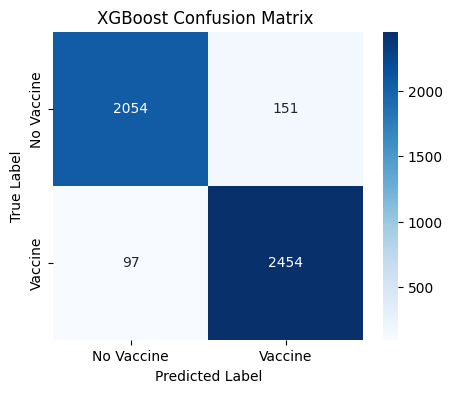

In [24]:
y_train_pred = pipeline.predict(X)

# Calculate metrics
acc = accuracy_score(y, y_train_pred)
prec = precision_score(y, y_train_pred)
rec = recall_score(y, y_train_pred)
f1 = f1_score(y, y_train_pred)
conf = confusion_matrix(y, y_train_pred)

print("XGBoost Metrics")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")
print("\nConfusion Matrix:")
print(conf)

plt.figure(figsize=(5,4))
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Vaccine', 'Vaccine'],
            yticklabels=['No Vaccine', 'Vaccine'])
plt.title('XGBoost Confusion Matrix ')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# SHAP

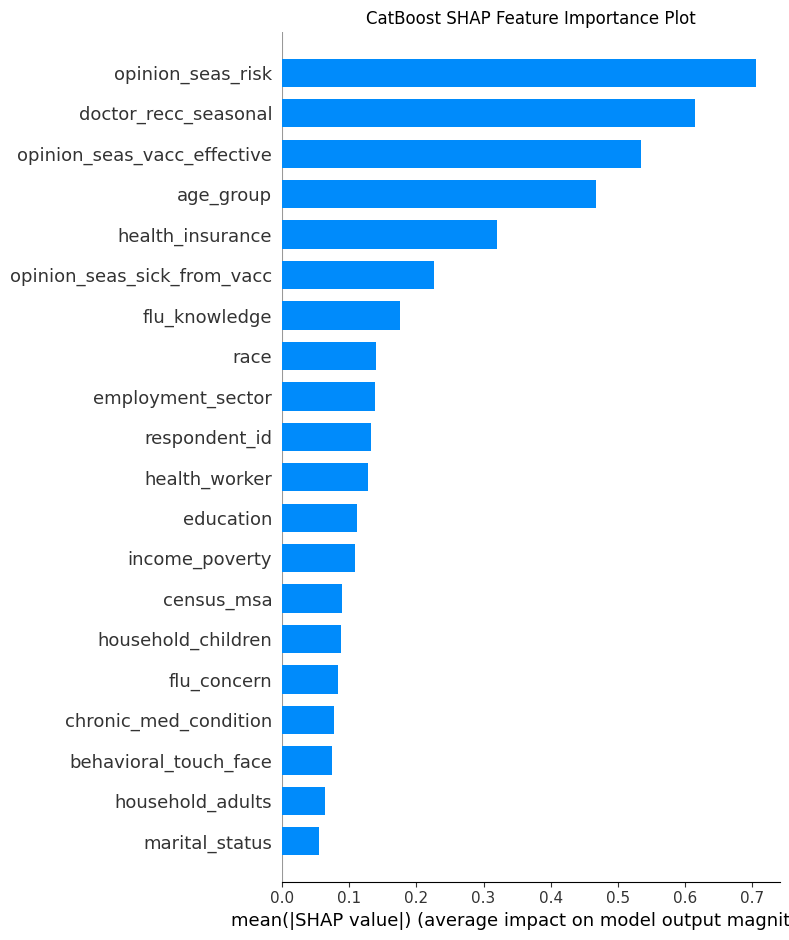

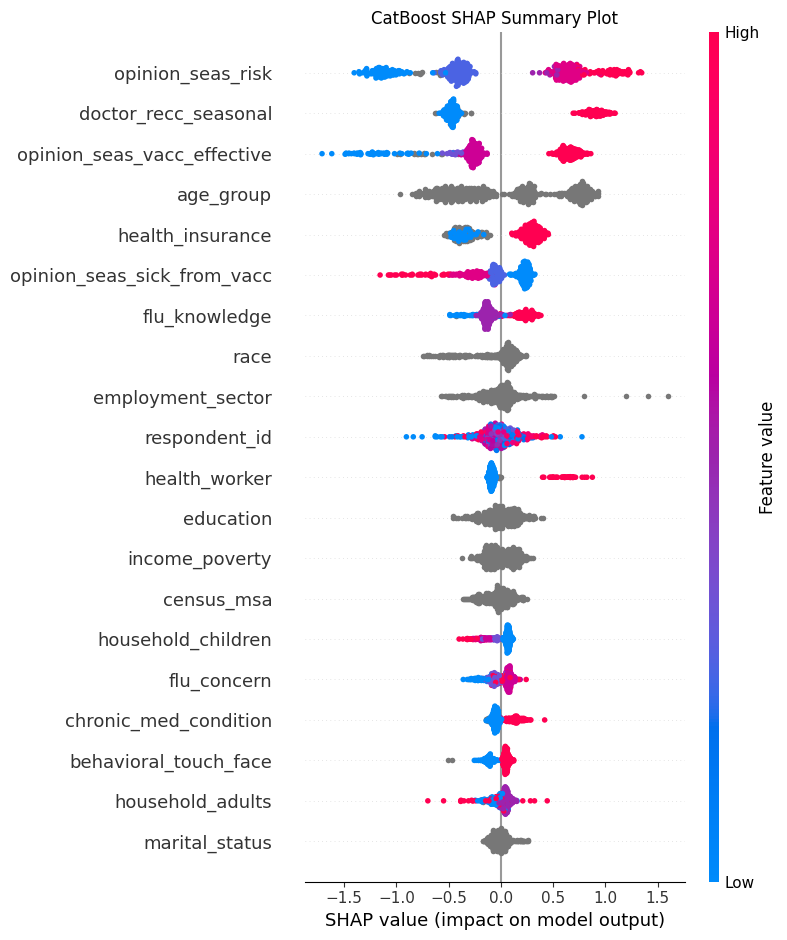

In [25]:
explainer_cat = shap.TreeExplainer(model)

X_for_catboost_shap = train.drop(columns=[TARGET])

for col in cat_features:
    if col in X_for_catboost_shap.columns:
        X_for_catboost_shap[col] = X_for_catboost_shap[col].astype(str)

X_sample = X_for_catboost_shap.sample(n=500, random_state=42)

shap_values_cat = explainer_cat.shap_values(X_sample)

shap.summary_plot(shap_values_cat, X_sample, plot_type="bar", show=False)
plt.title("CatBoost SHAP Feature Importance Plot")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values_cat, X_sample, show=False)
plt.title("CatBoost SHAP Summary Plot")
plt.tight_layout()
plt.show()

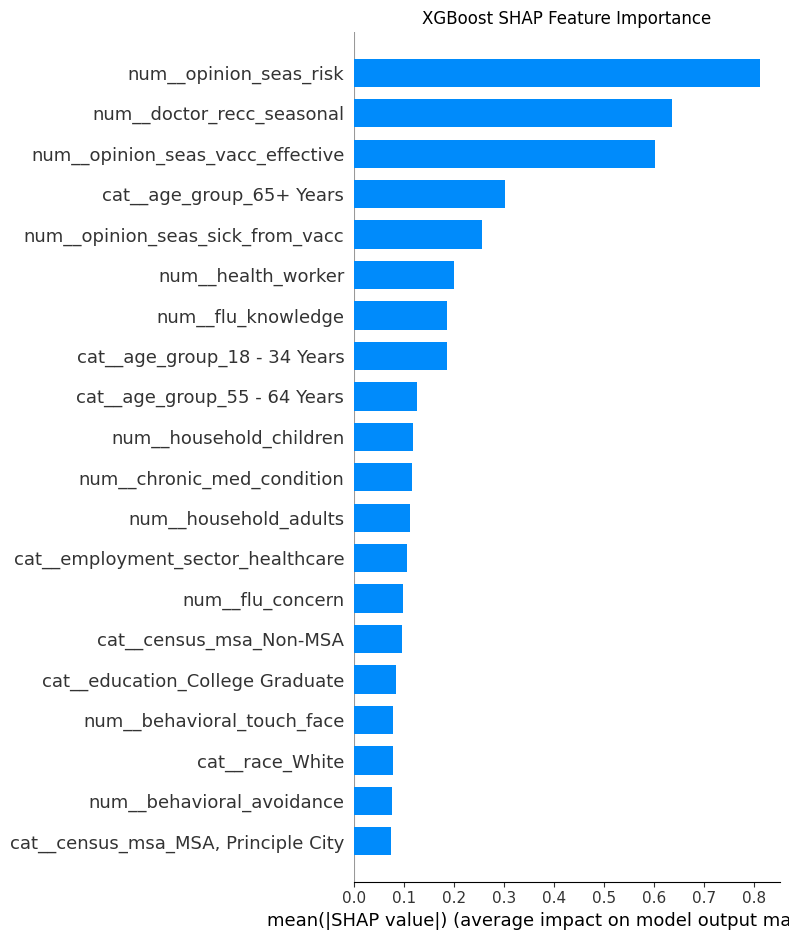

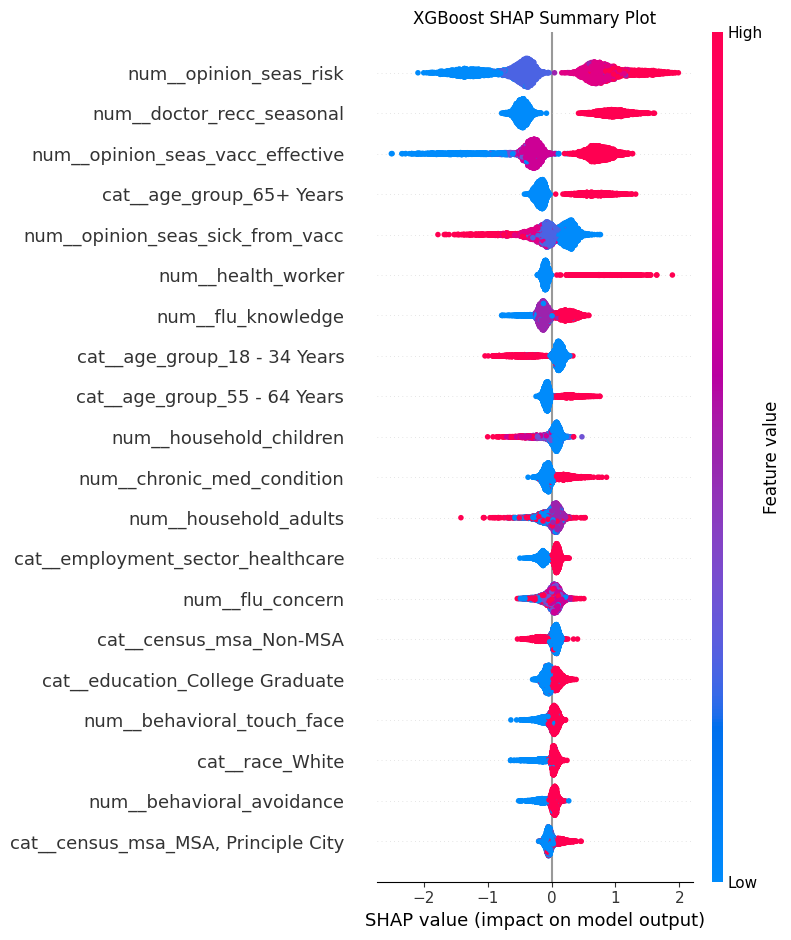

In [26]:
xgb_model = pipeline.named_steps['model']
preprocessor = pipeline.named_steps['prep']

X_processed = preprocessor.transform(X)
feature_names = preprocessor.get_feature_names_out()

explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_processed)

# Bar plot
shap.summary_plot(shap_values_xgb, X_processed, feature_names=feature_names,
                  plot_type="bar", show=False)
plt.title("XGBoost SHAP Feature Importance")
plt.tight_layout()
plt.show()

# Summary plot
shap.summary_plot(shap_values_xgb, X_processed, feature_names=feature_names, show=False)
plt.title("XGBoost SHAP Summary Plot")
plt.tight_layout()
plt.show()